🔤 TF-IDF 벡터화 중...
✅ TF-IDF 행렬 생성: (51, 3203)

🔍 KMeans 기반 클러스터 수 탐색 중...

k= 2 | Inertia=42.69 | Silhouette=0.0678
k= 3 | Inertia=39.95 | Silhouette=0.0880
k= 4 | Inertia=37.83 | Silhouette=0.0974
k= 5 | Inertia=36.34 | Silhouette=0.0840
k= 6 | Inertia=34.61 | Silhouette=0.0890
k= 7 | Inertia=32.69 | Silhouette=0.1058
k= 8 | Inertia=31.40 | Silhouette=0.1219
k= 9 | Inertia=29.67 | Silhouette=0.1320
k=10 | Inertia=28.11 | Silhouette=0.1386

🏁 Silhouette 기준 최적 k = 10


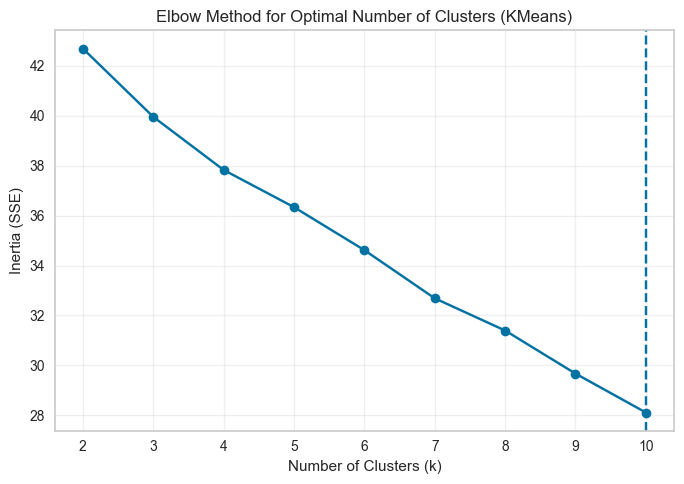

✅ Elbow 시각화 저장: ../images\kmeans_elbow_20251212_150345.png


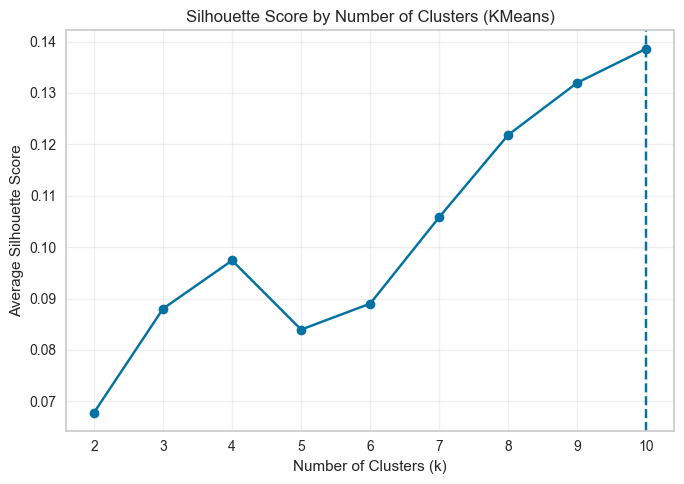

✅ Silhouette 시각화 저장: ../images\kmeans_silhouette_20251212_150345.png

✅ n_clusters = 10 로 설정 완료


In [12]:
# =============================================================================
# 4.4.2 Elbow & Silhouette 기반 최적 클러스터 수 탐색 (단독 실행 가능 버전)
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# (1) 디렉토리 기본값 (혹시 없으면 자동 생성)
if "IMAGE_DIR" not in globals():
    IMAGE_DIR = "../images"
os.makedirs(IMAGE_DIR, exist_ok=True)

# (2) tfidf_df가 없으면 여기서 생성
if "tfidf_df" not in globals():
    if "document_df" not in globals():
        raise RuntimeError("❌ document_df가 없습니다. 문서 DataFrame을 먼저 준비하세요.")
    if "processed_text" not in document_df.columns:
        raise RuntimeError("❌ document_df['processed_text'] 컬럼이 없습니다. 전처리 결과 컬럼명을 확인하세요.")

    print("🔤 TF-IDF 벡터화 중...")
    vectorizer = TfidfVectorizer(
        stop_words="english",
        max_features=5000,
        min_df=2,
        max_df=0.8
    )
    X = vectorizer.fit_transform(document_df["processed_text"].astype(str))
    tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
    print(f"✅ TF-IDF 행렬 생성: {tfidf_df.shape}\n")
else:
    print(f"✅ 기존 tfidf_df 사용: {tfidf_df.shape}\n")

# (3) k 탐색 범위
k_range = range(2, 11)
inertias = []
silhouette_scores = []

print("🔍 KMeans 기반 클러스터 수 탐색 중...\n")

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(tfidf_df)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(tfidf_df, labels))

    print(f"k={k:2d} | Inertia={kmeans.inertia_:.2f} | Silhouette={silhouette_scores[-1]:.4f}")

# (4) 최적 k (Silhouette 최대 기준)
best_k = list(k_range)[int(np.argmax(silhouette_scores))]
print(f"\n🏁 Silhouette 기준 최적 k = {best_k}")

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# (5) Elbow 시각화
plt.figure(figsize=(7, 5))
plt.plot(list(k_range), inertias, marker="o")
plt.axvline(best_k, linestyle="--")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method for Optimal Number of Clusters (KMeans)")
plt.grid(alpha=0.3)

elbow_path = os.path.join(IMAGE_DIR, f"kmeans_elbow_{timestamp}.png")
plt.tight_layout()
plt.savefig(elbow_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✅ Elbow 시각화 저장: {elbow_path}")

# (6) Silhouette 시각화
plt.figure(figsize=(7, 5))
plt.plot(list(k_range), silhouette_scores, marker="o")
plt.axvline(best_k, linestyle="--")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Average Silhouette Score")
plt.title("Silhouette Score by Number of Clusters (KMeans)")
plt.grid(alpha=0.3)

silhouette_path = os.path.join(IMAGE_DIR, f"kmeans_silhouette_{timestamp}.png")
plt.tight_layout()
plt.savefig(silhouette_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✅ Silhouette 시각화 저장: {silhouette_path}")

# (선택) 이후 코드에서 쓰도록 n_clusters에 저장
n_clusters = best_k
print(f"\n✅ n_clusters = {n_clusters} 로 설정 완료")
